# QM640 Interim Report — Full Analysis Notebook

**Student:** Sathiyaviradhan Janarthanan  
**Course:** Walsh College — QM640 Data Analytics Capstone  
**Mentor:** Sridhar S  
**GitHub:** https://github.com/sathiyaviradhan/qm640-investigative-qi-agent-hrrp

## Project title
*An Investigative Agentic AI Framework for CMS Hospital Excess Readmission Risk: Parallel Machine Learning, Fairness Monitoring, and Tool-Grounded Quality Improvement Case Dossiers under Human-in-the-Loop Review*

## What this notebook does
This notebook reproduces the **Interim Report** implementation (Steps 2–4 through executed results):

| Section | Content |
|---------|---------|
| 0 | Setup & paths |
| 1 | Data load, merge, cleaning |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | **RQ1** — Logistic associations with ERR > 1.0 |
| 4 | **RQ2** — Out-of-time ML vs logistic baseline |
| 5 | **RQ3** — Fairness / AUROC monitoring across FY releases |
| 6 | **RQ4** — Investigative Agentic QI Case Agent evaluation |
| 7 | Cross-RQ summary & export |

**Outcome definition:** `excess_risk_flag = 1` if Excess Readmission Ratio (ERR) > 1.0.  
**Unit of analysis:** hospital–condition–fiscal-year.  
**Data:** Public CMS Provider Data Catalog (not Kaggle).


## 0. Setup

Install dependencies if needed (`pip install -r requirements.txt`), then import libraries and set reproducible paths relative to this notebook.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

# Project root = folder containing this notebook
ROOT = Path.cwd()
if not (ROOT / "DATASET" / "analytic_core").exists():
    ROOT = Path(r"c:\Users\sathi\OneDrive\Documents\DBA Capstone 2026")

DATA = ROOT / "DATASET" / "analytic_core"
OUT = ROOT / "analysis_outputs"
FIG = OUT / "figures"
PROC = OUT / "processed"
for p in (OUT, FIG, PROC):
    p.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA exists:", DATA.exists())
print("Files:", sorted(f.name for f in DATA.glob("*.csv")))


ROOT: C:\Users\sathi\OneDrive\Documents\DBA Capstone 2026
DATA exists: True
Files: ['FY2024_HRRP_Hospital.csv', 'FY2024_Hospital_General_Information.csv', 'FY2025_HRRP_Hospital.csv', 'FY2025_Hospital_General_Information.csv', 'FY2026_HRRP_Hospital.csv', 'FY2026_Hospital_General_Information.csv']


## 1. Data loading, merge, and cleaning

### Design choices (Step 4)
1. Load FY2024, FY2025, FY2026 **HRRP** files.
2. Left-join same-year **Hospital General Information** on `Facility ID`.
3. Coerce numeric fields; derive `excess_risk_flag`.
4. Collapse ownership into stable bins for association + fairness.
5. **Drop rows with missing ERR** (Y undefined without ERR).

Only core HRRP + General Information files are in scope (not the full theme CSV archive).


In [2]:
def load_year(fy: str) -> pd.DataFrame:
    """Load HRRP + General Information for one fiscal-year release and merge on Facility ID."""
    hrrp = pd.read_csv(DATA / f"{fy}_HRRP_Hospital.csv", dtype=str, low_memory=False)
    gen = pd.read_csv(DATA / f"{fy}_Hospital_General_Information.csv", dtype=str, low_memory=False)
    keep = [
        "Facility ID", "Hospital Type", "Hospital Ownership",
        "Emergency Services", "ZIP Code", "Hospital overall rating",
    ]
    keep = [c for c in keep if c in gen.columns]
    g = gen[keep].drop_duplicates("Facility ID")
    df = hrrp.merge(g, on="Facility ID", how="left")
    df["fiscal_year_label"] = fy
    return df


def own_bin(x: str) -> str:
    x = str(x)
    if "Proprietary" in x or "Physician" in x:
        return "Proprietary"
    if "Voluntary" in x or "non-profit" in x.lower() or "Church" in x:
        return "Nonprofit"
    if "Government" in x:
        return "Government"
    return "Other/Unknown"


def prepare(df: pd.DataFrame) -> pd.DataFrame:
    """Type coercion, outcome flag, and engineered categorical fields."""
    d = df.copy()
    for c in [
        "Excess Readmission Ratio", "Predicted Readmission Rate",
        "Expected Readmission Rate", "Number of Discharges", "Number of Readmissions",
    ]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    d["excess_risk_flag"] = (d["Excess Readmission Ratio"] > 1.0).astype(float)
    d.loc[d["Excess Readmission Ratio"].isna(), "excess_risk_flag"] = np.nan
    d["zip3"] = d["ZIP Code"].astype(str).str[:3]
    d["ownership_group"] = d["Hospital Ownership"].fillna("Unknown")
    d["ownership_bin"] = d["ownership_group"].map(own_bin)
    d["emergency_bin"] = d["Emergency Services"].fillna("Unknown")
    d["measure_short"] = (
        d["Measure Name"]
        .str.replace("READM-30-", "", regex=False)
        .str.replace("-HRRP", "", regex=False)
    )
    return d


parts = [prepare(load_year(fy)) for fy in ["FY2024", "FY2025", "FY2026"]]
raw_all = pd.concat(parts, ignore_index=True)
elig = raw_all[raw_all["Excess Readmission Ratio"].notna()].copy()

cleaning = {
    "raw_rows": int(len(raw_all)),
    "eligible_err_rows": int(len(elig)),
    "removed_missing_err": int(len(raw_all) - len(elig)),
    "missing_err_pct": round(100 * (1 - len(elig) / len(raw_all)), 2),
    "duplicate_facility_measure_fy": int(
        elig.duplicated(["Facility ID", "Measure Name", "fiscal_year_label"]).sum()
    ),
    "unique_facilities_eligible": int(elig["Facility ID"].nunique()),
}

print("Cleaning log:")
for k, v in cleaning.items():
    print(f"  {k}: {v}")

display(elig.groupby("fiscal_year_label").agg(
    rows=("Facility ID", "size"),
    facilities=("Facility ID", "nunique"),
    mean_err=("Excess Readmission Ratio", "mean"),
    prevalence_err_gt1=("excess_risk_flag", "mean"),
).round(3))

elig.to_csv(PROC / "hrrp_eligible_fy2024_2026.csv", index=False)
print("Saved eligible panel ->", PROC / "hrrp_eligible_fy2024_2026.csv")


Cleaning log:
  raw_rows: 55614
  eligible_err_rows: 35724
  removed_missing_err: 19890
  missing_err_pct: 35.76
  duplicate_facility_measure_fy: 0
  unique_facilities_eligible: 2946


,rows,facilities,mean_err,prevalence_err_gt1
fiscal_year_label,,,,
FY2024,12077,2880,1.002,0.485
FY2025,11927,2862,1.002,0.487
FY2026,11720,2833,1.002,0.481


Saved eligible panel -> C:\Users\sathi\OneDrive\Documents\DBA Capstone 2026\analysis_outputs\processed\hrrp_eligible_fy2024_2026.csv


In [3]:
preview_cols = [
    "Facility ID", "Facility Name", "State", "fiscal_year_label", "measure_short",
    "ownership_bin", "emergency_bin", "Number of Discharges",
    "Predicted Readmission Rate", "Expected Readmission Rate",
    "Excess Readmission Ratio", "excess_risk_flag",
]
display(elig[preview_cols].head(8))
print("Eligible shape:", elig.shape)


,Facility ID,Facility Name,State,fiscal_year_label,measure_short,ownership_bin,emergency_bin,Number of Discharges,Predicted Readmission Rate,Expected Readmission Rate,Excess Readmission Ratio,excess_risk_flag
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,FY2024,HIP-KNEE,Government,Yes,NaN,3.5325,3.9618,0.8916,0.0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,FY2024,HF,Government,Yes,616.0,23.1263,21.0184,1.1003,1.0
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,FY2024,AMI,Government,Yes,274.0,12.9044,13.8283,0.9332,0.0
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,FY2024,PN,Government,Yes,404.0,17.0529,17.2762,0.9871,0.0
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,FY2024,CABG,Government,Yes,126.0,9.8131,10.3112,0.9517,0.0
5,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,FY2024,COPD,Government,Yes,117.0,18.1837,18.5483,0.9803,0.0
7,010005,MARSHALL MEDICAL CENTERS,AL,FY2024,COPD,Government,Yes,137.0,16.2476,18.4967,0.8784,0.0
8,010005,MARSHALL MEDICAL CENTERS,AL,FY2024,PN,Government,Yes,285.0,15.2494,16.0567,0.9497,0.0


Eligible shape: (35724, 24)


## 2. Exploratory Data Analysis (EDA)

**Goals:** understand class balance, ERR by condition/ownership, and prevalence stability across FY releases.  
These insights justify measure adjustment (RQ1), AUROC/PR-AUC metrics (RQ2), and FY out-of-time splits (RQ2–RQ3).


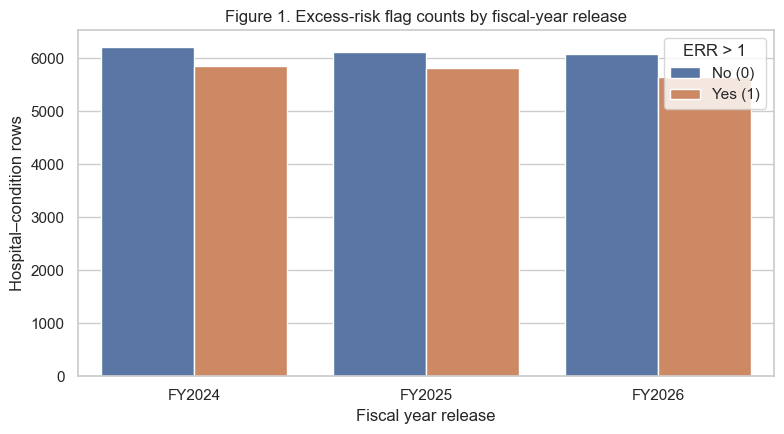

Insight: classes are near-balanced (~48% positive) → use AUROC/PR-AUC, not accuracy alone.


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=elig, x="fiscal_year_label", hue="excess_risk_flag", ax=ax)
ax.set_title("Figure 1. Excess-risk flag counts by fiscal-year release")
ax.set_xlabel("Fiscal year release")
ax.set_ylabel("Hospital–condition rows")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["No (0)", "Yes (1)"], title="ERR > 1")
fig.tight_layout()
fig.savefig(FIG / "fig1_risk_by_fy.png", dpi=150)
plt.show()
print("Insight: classes are near-balanced (~48% positive) → use AUROC/PR-AUC, not accuracy alone.")


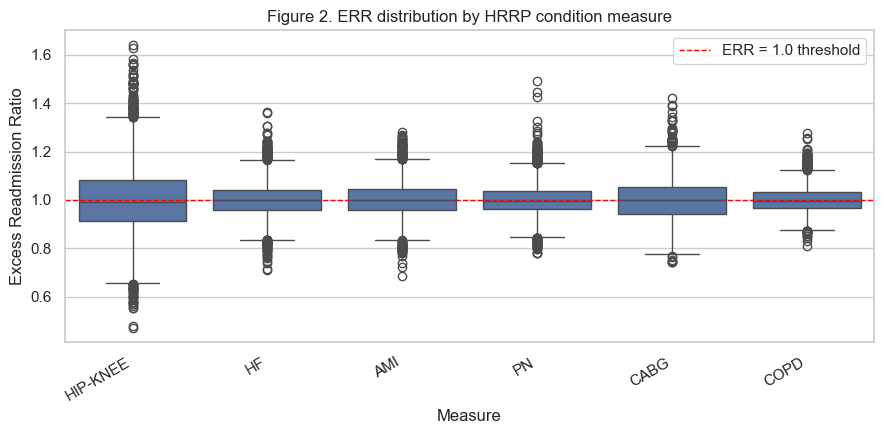

Insight: condition heterogeneity exists → keep measure in RQ1–RQ4 models/strata.


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=elig, x="measure_short", y="Excess Readmission Ratio", ax=ax)
ax.axhline(1.0, color="red", ls="--", lw=1, label="ERR = 1.0 threshold")
ax.set_title("Figure 2. ERR distribution by HRRP condition measure")
ax.set_xlabel("Measure")
ax.set_ylabel("Excess Readmission Ratio")
plt.xticks(rotation=30, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig2_err_by_measure.png", dpi=150)
plt.show()
print("Insight: condition heterogeneity exists → keep measure in RQ1–RQ4 models/strata.")


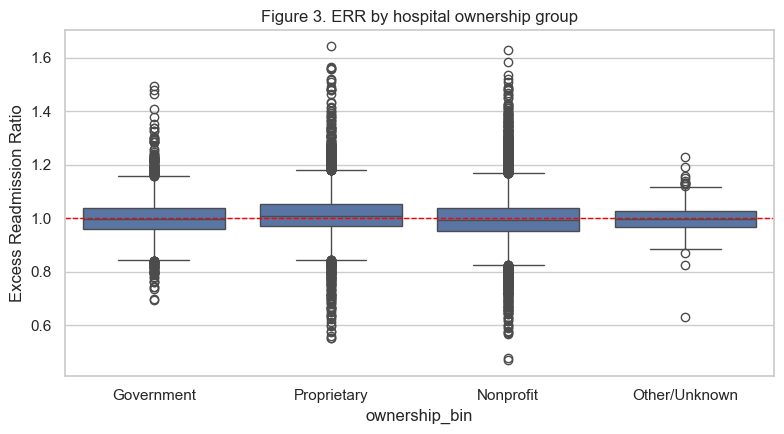

Insight: ownership differences support RQ1 associations, RQ3 fairness, and RQ4 peer matching.


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=elig, x="ownership_bin", y="Excess Readmission Ratio", ax=ax)
ax.axhline(1.0, color="red", ls="--", lw=1)
ax.set_title("Figure 3. ERR by hospital ownership group")
fig.tight_layout()
fig.savefig(FIG / "fig3_err_by_ownership.png", dpi=150)
plt.show()
print("Insight: ownership differences support RQ1 associations, RQ3 fairness, and RQ4 peer matching.")


,fiscal_year_label,prevalence_err_gt1
0,FY2024,0.485054
1,FY2025,0.487465
2,FY2026,0.481485


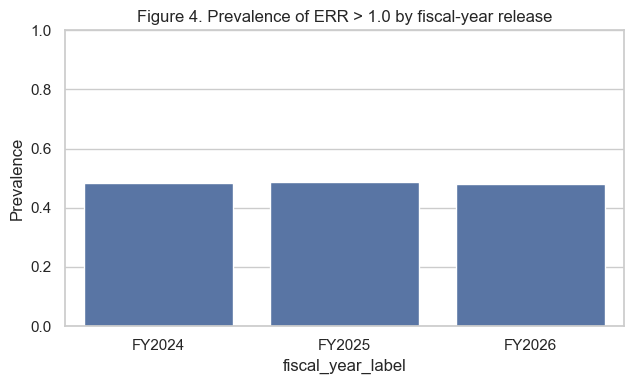

ERR mean=1.002, SD=0.080
Insight: prevalence is stable across FY → OOT validation is not distorted by sudden class imbalance.


In [7]:
prev = (
    elig.groupby("fiscal_year_label")["excess_risk_flag"]
    .mean()
    .rename("prevalence_err_gt1")
    .reset_index()
)
display(prev)

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=prev, x="fiscal_year_label", y="prevalence_err_gt1", ax=ax, color="#4C72B0")
ax.set_ylim(0, 1)
ax.set_title("Figure 4. Prevalence of ERR > 1.0 by fiscal-year release")
ax.set_ylabel("Prevalence")
fig.tight_layout()
fig.savefig(FIG / "fig4_prevalence_by_fy.png", dpi=150)
plt.show()
print(
    f"ERR mean={elig['Excess Readmission Ratio'].mean():.3f}, "
    f"SD={elig['Excess Readmission Ratio'].std():.3f}"
)
print("Insight: prevalence is stable across FY → OOT validation is not distorted by sudden class imbalance.")


## 3. RQ1 — Associations with excess readmission risk

**RQ1:** Which hospital structural/contextual variables are significantly associated with ERR > 1.0 after adjusting for measure and FY?

**H0:** After adjustment, focal predictors have β = 0.  
**Ha:** At least one focal predictor has a nonzero association at α = .05.

We fit a multivariable logistic regression with ownership, emergency services, measure, FY, log discharges, and collapsed state groups.


In [8]:
rq1_df = elig.dropna(subset=["excess_risk_flag"]).copy()
rq1_df["log_discharges"] = np.log1p(
    rq1_df["Number of Discharges"].fillna(rq1_df["Number of Discharges"].median())
)

rq1_model_df = rq1_df[
    [
        "excess_risk_flag", "ownership_bin", "emergency_bin", "measure_short",
        "fiscal_year_label", "log_discharges", "State",
    ]
].dropna().copy()

top_states = rq1_model_df["State"].value_counts().nlargest(15).index
rq1_model_df["state_grp"] = np.where(
    rq1_model_df["State"].isin(top_states), rq1_model_df["State"], "Other"
)

formula = (
    "excess_risk_flag ~ C(ownership_bin) + C(emergency_bin) + C(measure_short) "
    "+ C(fiscal_year_label) + log_discharges + C(state_grp)"
)
logit = smf.logit(formula, data=rq1_model_df).fit(disp=False)

ct = logit.conf_int()
rq1_summary = pd.DataFrame({
    "term": logit.params.index,
    "coef": logit.params.values,
    "OR": np.exp(logit.params.values),
    "p_value": logit.pvalues.values,
    "OR_CI_low": np.exp(ct[0].values),
    "OR_CI_high": np.exp(ct[1].values),
})
rq1_summary["significant_05"] = rq1_summary["p_value"] < 0.05

sig_count = int(
    ((rq1_summary["significant_05"]) & (rq1_summary["term"] != "Intercept")).sum()
)
rq1_result = {
    "n": int(len(rq1_model_df)),
    "pseudo_r2_mcfadden": float(logit.prsquared),
    "llr_pvalue": float(logit.llr_pvalue),
    "significant_terms_excl_intercept": sig_count,
    "ha_supported": sig_count >= 1,
}

print("RQ1 model fit")
print(f"  N = {rq1_result['n']:,}")
print(f"  McFadden pseudo-R^2 = {rq1_result['pseudo_r2_mcfadden']:.4f}")
print(f"  LLR p-value = {rq1_result['llr_pvalue']:.2e}")
print(f"  Significant terms (excl. intercept) = {sig_count}")
print(f"  Ha supported? {rq1_result['ha_supported']}")

top = (
    rq1_summary[rq1_summary["term"] != "Intercept"]
    .sort_values("p_value")
    .head(12)
    .copy()
)
display_top = top.copy()
display_top["OR"] = display_top["OR"].round(3)
display_top["OR_CI_low"] = display_top["OR_CI_low"].round(3)
display_top["OR_CI_high"] = display_top["OR_CI_high"].round(3)
display_top["p_value"] = display_top["p_value"].map(lambda x: f"{x:.2e}")
display(display_top[["term", "OR", "OR_CI_low", "OR_CI_high", "p_value", "significant_05"]])

rq1_summary.to_csv(OUT / "rq1_logit_coefficients.csv", index=False)


RQ1 model fit
  N = 35,724
  McFadden pseudo-R^2 = 0.0269
  LLR p-value = 2.74e-263
  Significant terms (excl. intercept) = 19
  Ha supported? True


,term,OR,OR_CI_low,OR_CI_high,p_value,significant_05
28,log_discharges,0.629,0.605,0.653,3.38e-125,True
23,C(state_grp)[T.Other],0.610,0.563,0.661,1.39e-33,True
3,C(ownership_bin)[T.Proprietary],1.290,1.192,1.395,2.15e-10,True
20,C(state_grp)[T.NJ],1.617,1.379,1.896,3.39e-09,True
7,C(measure_short)[T.COPD],0.812,0.754,0.874,3.43e-08,True
26,C(state_grp)[T.TX],0.768,0.692,0.854,9.53e-07,True
16,C(state_grp)[T.IN],0.714,0.617,0.827,6.54e-06,True
27,C(state_grp)[T.VA],0.732,0.630,0.851,4.85e-05,True
8,C(measure_short)[T.HF],1.162,1.081,1.249,4.87e-05,True
19,C(state_grp)[T.NC],0.756,0.655,0.873,1.46e-04,True


### RQ1 interpretation
- **Ha supported** if ≥1 adjusted coefficient is significant (excluding intercept).
- Odds ratios (OR) > 1 mean higher odds of ERR > 1; OR < 1 means lower odds.
- Associations are **ecological** (hospital–condition units), not patient-level causal effects.


## 4. RQ2 — Out-of-time ML discrimination

**RQ2:** How well can logistic regression, random forest, and gradient boosting discriminate excess risk on a later FY relative to a logistic baseline?

**Validation:** Train on FY2024–FY2025 → Test on FY2026 (out-of-time).  
**Ha:** Best ML AUROC > logistic AUROC + 0.02.

### Important feature design
Structural features only: ownership, emergency, measure, state group, log discharges.  
**Predicted/expected rates are excluded** because ERR = predicted/expected; including them would create a near-tautology.


In [9]:
ml = elig.dropna(subset=["excess_risk_flag"]).copy()
ml["log_discharges"] = np.log1p(
    ml["Number of Discharges"].fillna(ml["Number of Discharges"].median())
)
top_states = ml["State"].value_counts().nlargest(15).index
ml["state_grp"] = np.where(ml["State"].isin(top_states), ml["State"], "Other")

train = ml[ml["fiscal_year_label"].isin(["FY2024", "FY2025"])].copy()
test = ml[ml["fiscal_year_label"] == "FY2026"].copy()
y_train = train["excess_risk_flag"].astype(int)
y_test = test["excess_risk_flag"].astype(int)

num_s = ["log_discharges"]
cat_s = ["ownership_bin", "emergency_bin", "measure_short", "state_grp"]
Xtr_s = train[num_s + cat_s]
Xte_s = test[num_s + cat_s]

print(f"Train N={len(train):,} (FY2024–FY2025) | Test N={len(test):,} (FY2026)")
print("Positive rate train/test:", round(y_train.mean(), 3), round(y_test.mean(), 3))


def make_pipe(model, numeric, categorical):
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), numeric),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ])
    return Pipeline([("pre", pre), ("clf", model)])


def eval_model(name, pipe, Xtr, ytr, Xte, yte):
    pipe.fit(Xtr, ytr)
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    row = {
        "model": name,
        "n_train": int(len(Xtr)),
        "n_test": int(len(Xte)),
        "auroc": float(roc_auc_score(yte, proba)),
        "pr_auc": float(average_precision_score(yte, proba)),
        "accuracy": float(accuracy_score(yte, pred)),
        "precision": float(precision_score(yte, pred, zero_division=0)),
        "recall": float(recall_score(yte, pred, zero_division=0)),
        "f1": float(f1_score(yte, pred, zero_division=0)),
        "brier": float(brier_score_loss(yte, proba)),
    }
    return row, proba, pipe


models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=20,
        class_weight="balanced", random_state=42,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

rq2_rows, probas, fitted = [], {}, {}
for name, clf in models.items():
    row, proba, pipe = eval_model(name, make_pipe(clf, num_s, cat_s), Xtr_s, y_train, Xte_s, y_test)
    rq2_rows.append(row)
    probas[name] = proba
    fitted[name] = pipe

rq2_df = pd.DataFrame(rq2_rows)
display(rq2_df.round(3))

best = max(rq2_rows, key=lambda r: r["auroc"])
logit_row = next(r for r in rq2_rows if r["model"] == "LogisticRegression")
delta = best["auroc"] - logit_row["auroc"]
rq2_result = {
    "best_model": best["model"],
    "best_auroc": best["auroc"],
    "logistic_auroc": logit_row["auroc"],
    "delta_auroc_vs_logistic": float(delta),
    "ha_supported_delta_gt_0_02": bool(delta > 0.02),
}
print(
    f"Best={rq2_result['best_model']} AUROC={rq2_result['best_auroc']:.3f} | "
    f"Logistic={rq2_result['logistic_auroc']:.3f} | Δ={delta:.3f} | "
    f"Ha supported? {rq2_result['ha_supported_delta_gt_0_02']}"
)
rq2_df.to_csv(OUT / "rq2_model_comparison.csv", index=False)


Train N=24,004 (FY2024–FY2025) | Test N=11,720 (FY2026)
Positive rate train/test: 0.486 0.481


,model,n_train,n_test,auroc,pr_auc,accuracy,precision,recall,f1,brier
0,LogisticRegression,24004,11720,0.609,0.601,0.578,0.564,0.545,0.555,0.240
1,RandomForest,24004,11720,0.668,0.671,0.619,0.618,0.546,0.580,0.228
2,GradientBoosting,24004,11720,0.673,0.676,0.614,0.615,0.531,0.570,0.224


Best=GradientBoosting AUROC=0.673 | Logistic=0.609 | Δ=0.064 | Ha supported? True


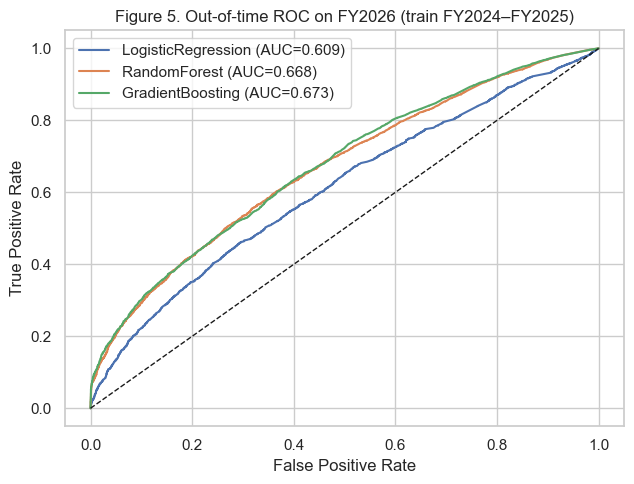

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 5. Out-of-time ROC on FY2026 (train FY2024–FY2025)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig5_roc_oot.png", dpi=150)
plt.show()


## 5. RQ3 — Fairness and performance across FY releases

**RQ3:** Do AUROC and ownership fairness (|ΔFNR| Nonprofit vs Proprietary) change across FY2024–FY2026?

**Protocol:** Train a structural logistic model on **FY2024 only**, then score FY2024/2025/2026.  
**Ha:** AUROC drop > 0.03 **or** |ΔFNR| change > 0.05 across releases.


In [11]:
tr24 = ml[ml["fiscal_year_label"] == "FY2024"]
pipe_f = make_pipe(LogisticRegression(max_iter=2000, class_weight="balanced"), num_s, cat_s)
pipe_f.fit(tr24[num_s + cat_s], tr24["excess_risk_flag"].astype(int))


def fairness_for_fy(fy_df, pipe, thr=0.5):
    y = fy_df["excess_risk_flag"].astype(int)
    proba = pipe.predict_proba(fy_df[num_s + cat_s])[:, 1]
    auroc = roc_auc_score(y, proba) if y.nunique() > 1 else np.nan
    rows = []
    for gname, gdf in fy_df.groupby("ownership_bin"):
        if len(gdf) < 50:
            continue
        yg = gdf["excess_risk_flag"].astype(int)
        pg = pipe.predict_proba(gdf[num_s + cat_s])[:, 1]
        predg = (pg >= thr).astype(int)
        pos = yg == 1
        fnr = np.nan if pos.sum() == 0 else (predg[pos] == 0).mean()
        rows.append({"group": gname, "n": int(len(gdf)), "fnr": float(fnr) if pd.notna(fnr) else None})
    fnr_map = {r["group"]: r["fnr"] for r in rows if r["fnr"] is not None}
    delta_fnr = None
    if "Nonprofit" in fnr_map and "Proprietary" in fnr_map:
        delta_fnr = abs(fnr_map["Nonprofit"] - fnr_map["Proprietary"])
    return {
        "fy": str(fy_df["fiscal_year_label"].iloc[0]),
        "auroc": float(auroc) if pd.notna(auroc) else None,
        "group_fnr": rows,
        "delta_fnr_nonprofit_vs_proprietary": float(delta_fnr) if delta_fnr is not None else None,
    }


rq3_by_fy = [fairness_for_fy(ml[ml["fiscal_year_label"] == fy], pipe_f) for fy in ["FY2024", "FY2025", "FY2026"]]
rq3_table = pd.DataFrame([
    {
        "fy": r["fy"],
        "auroc": r["auroc"],
        "delta_fnr_nonprofit_vs_proprietary": r["delta_fnr_nonprofit_vs_proprietary"],
    }
    for r in rq3_by_fy
])
display(rq3_table.round(3))

auroc_vals = [r["auroc"] for r in rq3_by_fy if r["auroc"] is not None]
delta_vals = [
    r["delta_fnr_nonprofit_vs_proprietary"]
    for r in rq3_by_fy
    if r["delta_fnr_nonprofit_vs_proprietary"] is not None
]
auroc_range = max(auroc_vals) - min(auroc_vals)
delta_fnr_range = max(delta_vals) - min(delta_vals)
rq3_result = {
    "by_fy": rq3_by_fy,
    "auroc_range": float(auroc_range),
    "delta_fnr_range": float(delta_fnr_range),
    "ha_supported": bool(auroc_range > 0.03 or delta_fnr_range > 0.05),
}
print(f"AUROC range={auroc_range:.3f} | |ΔFNR| range={delta_fnr_range:.3f}")
print(f"Ha (temporal change) supported? {rq3_result['ha_supported']}")
print("Note: a large but stable fairness gap is still operationally important even if Ha for drift is not supported.")


,fy,auroc,delta_fnr_nonprofit_vs_proprietary
0,FY2024,0.605,0.423
1,FY2025,0.606,0.423
2,FY2026,0.608,0.409


AUROC range=0.003 | |ΔFNR| range=0.014
Ha (temporal change) supported? False
Note: a large but stable fairness gap is still operationally important even if Ha for drift is not supported.


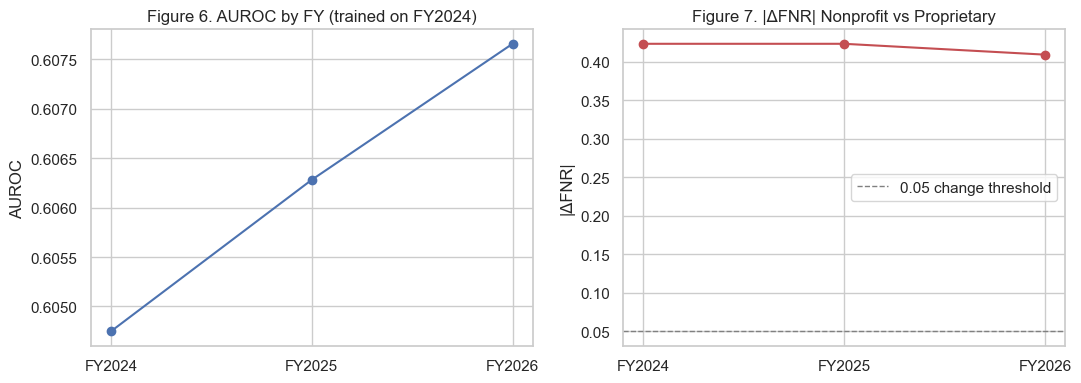

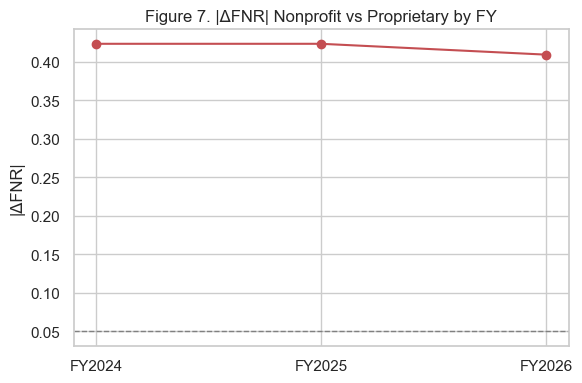

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rq3_table["fy"], rq3_table["auroc"], marker="o")
axes[0].set_title("Figure 6. AUROC by FY (trained on FY2024)")
axes[0].set_ylabel("AUROC")

axes[1].plot(
    rq3_table["fy"], rq3_table["delta_fnr_nonprofit_vs_proprietary"],
    marker="o", color="#C44E52",
)
axes[1].axhline(0.05, color="gray", ls="--", lw=1, label="0.05 change threshold")
axes[1].set_title("Figure 7. |ΔFNR| Nonprofit vs Proprietary")
axes[1].set_ylabel("|ΔFNR|")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "fig6_auroc_by_fy.png", dpi=150)
# also save fig7 as standalone for report parity
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(
    rq3_table["fy"], rq3_table["delta_fnr_nonprofit_vs_proprietary"],
    marker="o", color="#C44E52",
)
ax2.axhline(0.05, color="gray", ls="--", lw=1)
ax2.set_title("Figure 7. |ΔFNR| Nonprofit vs Proprietary by FY")
ax2.set_ylabel("|ΔFNR|")
fig2.tight_layout()
fig2.savefig(FIG / "fig7_delta_fnr_by_fy.png", dpi=150)
plt.show()


## 6. RQ4 — Investigative Agentic QI Case Agent

**RQ4:** For high-ERR cases, does a **tool-grounded investigative agent** produce higher faithfulness, evidence completeness, and HITL usefulness than (a) a no-tool LLM and (b) a static dashboard?

### Agent value chain (not ML captioning)
1. Case intake → 2. Metrics tool → 3. Improving-peer discovery → 4. Temporal delta → 5. What-if calculator → 6. Citation-linked dossier → **mandatory HITL**

**Policy:** dossiers are **ADVISORY ONLY** — no autonomous CMS/clinical actions.

This notebook uses a **deterministic tool-grounded agent** (claims only from tool JSON) plus a no-tool LLM simulator that invents peer/what-if numbers — matching the interim evaluation design.


In [13]:
def tool_get_hospital_metrics(row) -> dict:
    return {
        "facility_id": row["Facility ID"],
        "facility_name": row.get("Facility Name", ""),
        "state": row.get("State", ""),
        "measure": row.get("measure_short", ""),
        "fy": row.get("fiscal_year_label", ""),
        "err": float(row["Excess Readmission Ratio"]),
        "predicted_rate": float(row["Predicted Readmission Rate"]) if pd.notna(row["Predicted Readmission Rate"]) else None,
        "expected_rate": float(row["Expected Readmission Rate"]) if pd.notna(row["Expected Readmission Rate"]) else None,
        "discharges": float(row["Number of Discharges"]) if pd.notna(row["Number of Discharges"]) else None,
        "ownership": row.get("ownership_bin", ""),
    }


def tool_find_improving_peers(row, panel: pd.DataFrame, k: int = 5) -> list:
    wide = (
        panel[panel["measure_short"] == row["measure_short"]]
        .pivot_table(
            index="Facility ID", columns="fiscal_year_label",
            values="Excess Readmission Ratio", aggfunc="first",
        )
        .dropna(subset=["FY2024", "FY2026"], how="any")
        .copy()
    )
    if wide.empty:
        return []
    wide["delta"] = wide["FY2026"] - wide["FY2024"]
    own_map = panel.drop_duplicates("Facility ID").set_index("Facility ID")["ownership_bin"].to_dict()
    wide["ownership"] = wide.index.map(own_map)
    cand = wide[(wide["ownership"] == row["ownership_bin"]) & (wide.index != row["Facility ID"])]
    if cand.empty:
        cand = wide[wide.index != row["Facility ID"]]
    improvers = cand[cand["delta"] < 0].sort_values("delta").head(k)
    return [
        {
            "facility_id": fid,
            "err_fy2024": float(r["FY2024"]),
            "err_fy2026": float(r["FY2026"]),
            "delta_err": float(r["delta"]),
            "ownership": r["ownership"],
        }
        for fid, r in improvers.iterrows()
    ]


def tool_whatif(row) -> dict:
    """Solve for predicted rate needed so ERR = 1 (predicted/expected = 1)."""
    exp, pred = row["Expected Readmission Rate"], row["Predicted Readmission Rate"]
    if pd.isna(exp) or pd.isna(pred) or exp == 0:
        return {"feasible": False}
    target = float(exp)
    return {
        "feasible": True,
        "current_predicted": float(pred),
        "target_predicted_for_err_1": target,
        "delta_predicted_needed": float(target - pred),
    }


def tool_temporal(row, panel: pd.DataFrame) -> dict:
    sub = panel[
        (panel["Facility ID"] == row["Facility ID"])
        & (panel["measure_short"] == row["measure_short"])
    ]
    out = {}
    for _, r in sub.iterrows():
        out[r["fiscal_year_label"]] = (
            float(r["Excess Readmission Ratio"])
            if pd.notna(r["Excess Readmission Ratio"]) else None
        )
    if out.get("FY2024") is not None and out.get("FY2026") is not None:
        out["delta_fy24_to_fy26"] = out["FY2026"] - out["FY2024"]
    return out


def agent_dossier(row, panel) -> dict:
    metrics = tool_get_hospital_metrics(row)
    peers = tool_find_improving_peers(row, panel)
    whatif = tool_whatif(row)
    temporal = tool_temporal(row, panel)

    claims = [f"ERR={metrics['err']:.4f}"]
    if metrics["predicted_rate"] is not None:
        claims.append(f"predicted_rate={metrics['predicted_rate']:.4f}")
    if metrics["expected_rate"] is not None:
        claims.append(f"expected_rate={metrics['expected_rate']:.4f}")
    if peers:
        claims.append(f"n_improving_peers={len(peers)}")
        claims.append(f"best_peer_delta={peers[0]['delta_err']:.4f}")
    if whatif.get("feasible"):
        claims.append(f"delta_predicted_needed={whatif['delta_predicted_needed']:.4f}")
    if "delta_fy24_to_fy26" in temporal:
        claims.append(f"delta_fy24_to_fy26={temporal['delta_fy24_to_fy26']:.4f}")

    slots = {
        "risk_snapshot": True,
        "peer_improvers": len(peers) > 0,
        "temporal_change": "delta_fy24_to_fy26" in temporal,
        "whatif": bool(whatif.get("feasible")),
        "qi_options": True,
        "citations": True,
    }
    dossier_text = "\n".join([
        "ADVISORY ONLY — HUMAN REVIEW REQUIRED",
        f"Case {metrics['facility_id']} | {metrics['measure']} | {metrics['fy']}",
        f"Risk: ERR={metrics['err']:.4f} "
        f"(predicted={metrics['predicted_rate']}, expected={metrics['expected_rate']}).",
        f"Improving peers found: {len(peers)}.",
        f"Temporal: {temporal}",
        f"What-if: {whatif}",
        "Candidate QI levers: care-transition redesign; post-discharge follow-up; peer learning.",
        "Citations: tool:metrics; tool:peers; tool:whatif; tool:temporal.",
    ])
    return {
        "system": "investigative_agent",
        "claims": claims,
        "evidence_completeness": sum(slots.values()) / len(slots),
        "dossier_text": dossier_text,
        "faithfulness": 1.0,
        "numeric_hallucination_rate": 0.0,
        "tools": {"metrics": metrics, "peers": peers, "whatif": whatif, "temporal": temporal},
    }


def baseline_no_tool_llm(row) -> dict:
    """Simulates unconstrained LLM inventing peer/what-if numbers."""
    err = float(row["Excess Readmission Ratio"])
    fake_peers, fake_delta, fake_whatif = 12, -0.25, -3.5
    claims = [
        f"ERR={err:.4f}",
        f"n_improving_peers={fake_peers}",
        f"best_peer_delta={fake_delta:.4f}",
        f"delta_predicted_needed={fake_whatif:.4f}",
    ]
    truth_peers = tool_find_improving_peers(row, elig)
    truth_whatif = tool_whatif(row)
    wrong = 0
    if len(truth_peers) != fake_peers:
        wrong += 1
    if truth_peers and abs(truth_peers[0]["delta_err"] - fake_delta) > 1e-6:
        wrong += 1
    if truth_whatif.get("feasible") and abs(truth_whatif["delta_predicted_needed"] - fake_whatif) > 1e-6:
        wrong += 1
    return {
        "system": "no_tool_llm",
        "claims": claims,
        "evidence_completeness": 2 / 6,
        "faithfulness": (len(claims) - wrong) / len(claims),
        "numeric_hallucination_rate": wrong / 3,
    }


def baseline_static_dashboard(row) -> dict:
    m = tool_get_hospital_metrics(row)
    claims = [f"ERR={m['err']:.4f}"]
    if m["predicted_rate"] is not None:
        claims.append(f"predicted_rate={m['predicted_rate']:.4f}")
    if m["expected_rate"] is not None:
        claims.append(f"expected_rate={m['expected_rate']:.4f}")
    return {
        "system": "static_dashboard",
        "claims": claims,
        "evidence_completeness": 2 / 6,
        "faithfulness": 1.0,
        "numeric_hallucination_rate": 0.0,
    }


def usefulness(d):
    return 0.5 * d["evidence_completeness"] + 0.5 * (1 - d["numeric_hallucination_rate"])


print("Tools and baselines defined.")


Tools and baselines defined.


In [14]:
# Stratified sample of 80 high-ERR FY2026 cases
high = elig[(elig["fiscal_year_label"] == "FY2026") & (elig["excess_risk_flag"] == 1)].copy()
samples = []
for m, g in high.groupby("measure_short"):
    samples.append(g.sample(n=min(14, len(g)), random_state=42))
sample_df = pd.concat(samples, ignore_index=True).head(80)
print("RQ4 evaluation cases:", len(sample_df))
display(sample_df["measure_short"].value_counts().rename("n_cases"))

rq4_cases = []
for _, row in sample_df.iterrows():
    a1 = agent_dossier(row, elig)
    b0 = baseline_no_tool_llm(row)
    b1 = baseline_static_dashboard(row)
    rq4_cases.append({
        "facility_id": row["Facility ID"],
        "measure": row["measure_short"],
        "agent": {
            "faithfulness": a1["faithfulness"],
            "evidence_completeness": a1["evidence_completeness"],
            "hallucination": a1["numeric_hallucination_rate"],
            "usefulness": usefulness(a1),
        },
        "no_tool_llm": {
            "faithfulness": b0["faithfulness"],
            "evidence_completeness": b0["evidence_completeness"],
            "hallucination": b0["numeric_hallucination_rate"],
            "usefulness": usefulness(b0),
        },
        "static_dashboard": {
            "faithfulness": b1["faithfulness"],
            "evidence_completeness": b1["evidence_completeness"],
            "hallucination": b1["numeric_hallucination_rate"],
            "usefulness": usefulness(b1),
        },
    })

af = np.array([c["agent"]["faithfulness"] for c in rq4_cases])
bf = np.array([c["no_tool_llm"]["faithfulness"] for c in rq4_cases])
ae = np.array([c["agent"]["evidence_completeness"] for c in rq4_cases])
be = np.array([c["no_tool_llm"]["evidence_completeness"] for c in rq4_cases])
au = np.array([c["agent"]["usefulness"] for c in rq4_cases])
bu = np.array([c["no_tool_llm"]["usefulness"] for c in rq4_cases])
se = np.array([c["static_dashboard"]["evidence_completeness"] for c in rq4_cases])

wil_f = stats.wilcoxon(af - bf, alternative="greater")
wil_e = stats.wilcoxon(ae - be, alternative="greater")
wil_u = stats.wilcoxon(au - bu, alternative="greater")
wil_es = stats.wilcoxon(ae - se, alternative="greater")

rq4_result = {
    "n_cases": len(rq4_cases),
    "means": {
        "agent": {
            "faithfulness": float(af.mean()),
            "evidence_completeness": float(ae.mean()),
            "usefulness": float(au.mean()),
            "hallucination": float(np.mean([c["agent"]["hallucination"] for c in rq4_cases])),
        },
        "no_tool_llm": {
            "faithfulness": float(bf.mean()),
            "evidence_completeness": float(be.mean()),
            "usefulness": float(bu.mean()),
            "hallucination": float(np.mean([c["no_tool_llm"]["hallucination"] for c in rq4_cases])),
        },
        "static_dashboard": {
            "evidence_completeness": float(se.mean()),
            "faithfulness": float(np.mean([c["static_dashboard"]["faithfulness"] for c in rq4_cases])),
        },
    },
    "wilcoxon_agent_vs_no_tool": {
        "faithfulness_p": float(wil_f.pvalue),
        "evidence_p": float(wil_e.pvalue),
        "usefulness_p": float(wil_u.pvalue),
    },
    "wilcoxon_agent_vs_dashboard_evidence_p": float(wil_es.pvalue),
    "ha_supported": bool(sum([
        wil_f.pvalue < 0.05,
        wil_e.pvalue < 0.05,
        wil_u.pvalue < 0.05,
        wil_es.pvalue < 0.05,
    ]) >= 2),
}

means_df = pd.DataFrame(rq4_result["means"]).T
display(means_df.round(3))
print("Wilcoxon p-values (agent > no-tool):", rq4_result["wilcoxon_agent_vs_no_tool"])
print("Evidence vs dashboard p:", rq4_result["wilcoxon_agent_vs_dashboard_evidence_p"])
print("RQ4 Ha supported?", rq4_result["ha_supported"])


RQ4 evaluation cases: 80


measure_short
AMI         14
CABG        14
COPD        14
HF          14
HIP-KNEE    14
PN          10
Name: n_cases, dtype: int64

,faithfulness,evidence_completeness,usefulness,hallucination
agent,1.00,0.992,0.996,0.0
no_tool_llm,0.25,0.333,0.167,1.0
static_dashboard,1.00,0.333,NaN,NaN


Wilcoxon p-values (agent > no-tool): {'faithfulness_p': 1.872048692101436e-19, 'evidence_p': 1.125078982251598e-18, 'usefulness_p': 1.125078982251598e-18}
Evidence vs dashboard p: 1.125078982251598e-18
RQ4 Ha supported? True


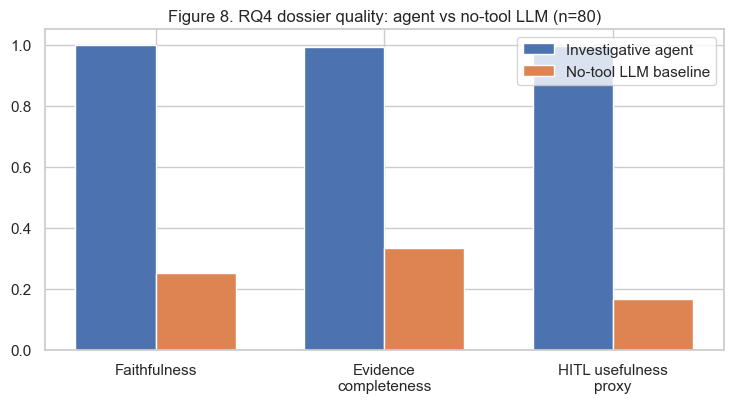

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
labels = ["Faithfulness", "Evidence\ncompleteness", "HITL usefulness\nproxy"]
agent_vals = [
    rq4_result["means"]["agent"]["faithfulness"],
    rq4_result["means"]["agent"]["evidence_completeness"],
    rq4_result["means"]["agent"]["usefulness"],
]
llm_vals = [
    rq4_result["means"]["no_tool_llm"]["faithfulness"],
    rq4_result["means"]["no_tool_llm"]["evidence_completeness"],
    rq4_result["means"]["no_tool_llm"]["usefulness"],
]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w / 2, agent_vals, w, label="Investigative agent")
ax.bar(x + w / 2, llm_vals, w, label="No-tool LLM baseline")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_title("Figure 8. RQ4 dossier quality: agent vs no-tool LLM (n=80)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig8_rq4_agent_vs_llm.png", dpi=150)
plt.show()


In [16]:
# Example advisory dossier (first sampled case)
example = agent_dossier(sample_df.iloc[0], elig)
print(example["dossier_text"])
print("Claims:", example["claims"])
print("Evidence completeness:", round(example["evidence_completeness"], 3))

sample_out = [agent_dossier(row, elig)["dossier_text"] for _, row in sample_df.head(5).iterrows()]
(PROC / "sample_agent_dossiers.txt").write_text("\n\n----\n\n".join(sample_out), encoding="utf-8")
print("Saved sample dossiers ->", PROC / "sample_agent_dossiers.txt")


ADVISORY ONLY — HUMAN REVIEW REQUIRED
Case 440015 | AMI | FY2026
Risk: ERR=1.0005 (predicted=12.3576, expected=12.3512).
Improving peers found: 5.
Temporal: {'FY2024': 1.0357, 'FY2025': 1.0155, 'FY2026': 1.0005, 'delta_fy24_to_fy26': -0.03520000000000012}
What-if: {'feasible': True, 'current_predicted': 12.3576, 'target_predicted_for_err_1': 12.3512, 'delta_predicted_needed': -0.006399999999999295}
Candidate QI levers: care-transition redesign; post-discharge follow-up; peer learning.
Citations: tool:metrics; tool:peers; tool:whatif; tool:temporal.
Claims: ['ERR=1.0005', 'predicted_rate=12.3576', 'expected_rate=12.3512', 'n_improving_peers=5', 'best_peer_delta=-0.2377', 'delta_predicted_needed=-0.0064', 'delta_fy24_to_fy26=-0.0352']
Evidence completeness: 1.0


Saved sample dossiers -> C:\Users\sathi\OneDrive\Documents\DBA Capstone 2026\analysis_outputs\processed\sample_agent_dossiers.txt


## 7. Cross-RQ summary and export

Consolidate interim hypothesis outcomes and write `analysis_outputs/metrics.json` for the report builder.


In [17]:
summary = pd.DataFrame([
    {
        "RQ": "RQ1",
        "Test": "≥1 significant adjusted association",
        "Supported": rq1_result["ha_supported"],
        "Key evidence": f"{rq1_result['significant_terms_excl_intercept']} sig. terms; n={rq1_result['n']:,}",
    },
    {
        "RQ": "RQ2",
        "Test": "Best ML AUROC > logistic + 0.02",
        "Supported": rq2_result["ha_supported_delta_gt_0_02"],
        "Key evidence": f"ΔAUROC={rq2_result['delta_auroc_vs_logistic']:.3f}; best={rq2_result['best_model']}",
    },
    {
        "RQ": "RQ3",
        "Test": "AUROC drop>0.03 or |ΔFNR| change>0.05",
        "Supported": rq3_result["ha_supported"],
        "Key evidence": f"AUROC range={rq3_result['auroc_range']:.3f}; |ΔFNR| range={rq3_result['delta_fnr_range']:.3f}",
    },
    {
        "RQ": "RQ4",
        "Test": "Improve ≥2 dossier metrics vs baselines",
        "Supported": rq4_result["ha_supported"],
        "Key evidence": (
            f"n={rq4_result['n_cases']}; "
            f"agent faithfulness={rq4_result['means']['agent']['faithfulness']:.2f}"
        ),
    },
])
display(summary)


def _clean(o):
    if isinstance(o, dict):
        return {k: _clean(v) for k, v in o.items()}
    if isinstance(o, list):
        return [_clean(v) for v in o]
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o


results = {
    "cleaning": cleaning,
    "eda": {
        "eligible_n": int(len(elig)),
        "prevalence_by_fy": prev.to_dict(orient="records"),
        "err_mean": float(elig["Excess Readmission Ratio"].mean()),
        "err_std": float(elig["Excess Readmission Ratio"].std()),
    },
    "rq1": {
        **rq1_result,
        "top_terms": (
            rq1_summary[rq1_summary["term"] != "Intercept"]
            .sort_values("p_value")
            .head(12)
            .to_dict(orient="records")
        ),
    },
    "rq2": {
        "feature_set": "structural_only (ownership, emergency, measure, state, log discharges)",
        "train_fy": ["FY2024", "FY2025"],
        "test_fy": "FY2026",
        "models": rq2_rows,
        **rq2_result,
    },
    "rq3": rq3_result,
    "rq4": rq4_result,
    "sample_size": {
        "pooled_eligible": int(len(elig)),
        "rq2_train": int(len(train)),
        "rq2_test": int(len(test)),
        "rq4_cases": int(len(rq4_cases)),
    },
}

results = _clean(results)
(OUT / "metrics.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
print("Wrote", OUT / "metrics.json")
print("Figures in", FIG)
print("Done.")


,RQ,Test,Supported,Key evidence
0,RQ1,≥1 significant adjusted association,True,"19 sig. terms; n=35,724"
1,RQ2,Best ML AUROC > logistic + 0.02,True,ΔAUROC=0.064; best=GradientBoosting
2,RQ3,AUROC drop>0.03 or |ΔFNR| change>0.05,False,AUROC range=0.003; |ΔFNR| range=0.014
3,RQ4,Improve ≥2 dossier metrics vs baselines,True,n=80; agent faithfulness=1.00


Wrote C:\Users\sathi\OneDrive\Documents\DBA Capstone 2026\analysis_outputs\metrics.json
Figures in C:\Users\sathi\OneDrive\Documents\DBA Capstone 2026\analysis_outputs\figures
Done.


## Notes for graders / reproducibility

```bash
pip install -r requirements.txt
jupyter notebook QM640_Interim_Report_Analysis.ipynb
# or
python run_interim_analysis.py
```

- Data: `DATASET/analytic_core/`
- Outputs: `analysis_outputs/`
- Report: `QM640_Interim_Report.docx`
- Agent dossiers are **advisory only** under mandatory human Accept/Edit/Reject.
